# Active Transcription Scoring on Real Spinal Cord Injury Data

This tutorial runs the full `active_score` workflow — the velocity-aware
path for data **with** spliced/unspliced (or mature/nascent) layers — on a
real dataset: endothelial cells (EC) from adult mouse spinal cord, comparing
**uninjured controls (UN, 3 replicates)** against **spinal cord injury (SCI,
3 replicates)**.

The data are a subset of:

> Squair, J.W., Gautier, M., Kathe, C., Anderson, M.A., James, N.D., Hutson,
> T.H., Hudelle, R., Qaiser, T., Matson, K.J.E., Barraud, Q., Levine, A.J.,
> La Manno, G., Skinnider, M.A., Courtine, G. (2021). **Confronting false
> discoveries in single-cell differential expression.** *Nature
> Communications* 12, 5692. DOI:
> [10.1038/s41467-021-25960-2](https://doi.org/10.1038/s41467-021-25960-2)
> (GEO [GSE165003](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE165003)).
> See {doc}`../references` for the full citation.

:::{note}
This choice of dataset is not an accident. Squair et al. (2021) is *about*
the false-discovery risk of treating single cells as independent replicates
in differential expression — exactly the pseudoreplication problem that
motivates scATrans's `use_pseudobulk`, `use_mixed_model`, and
`use_permutation` machinery. We will see this play out directly on real
data below: a small (3 vs. 3 sample) design has genuinely limited power,
and the honest result is that few or no genes clear a strict FDR threshold.
We show that outcome as-is rather than manufacturing a cleaner-looking
example.
:::

**What `active_score` computes**: for each gene, a composite score combining
(1) standard differential expression (logFC, adjusted p-value) with (2) a
reference-gamma **unspliced excess** term — how much more unspliced/nascent
RNA a gene shows in the target group than expected from a reference-group
U/S ratio — after optional bias correction for gene length and intron
count. The result is a **ranking heuristic**, not a p-value; see
{doc}`../statistical_guidance`.

In [1]:
%matplotlib inline

In [2]:
import sys
sys.path.insert(0, "../../src")  # use the in-repo scatrans, not any installed copy

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import scatrans as scat

print("scatrans", scat.__file__)
sc.settings.verbosity = 1

scatrans /home/lieber/scATrans-main/docs/tutorials/../../src/scatrans/__init__.py


## Load the data

`EC.h5ad` already contains `spliced` / `unspliced` layers (plus kb_python's
`mature` / `nascent` / `ambiguous`, which scATrans does not need here since
`spliced` / `unspliced` are already correctly named).

In [3]:
adata = sc.read_h5ad("../../EC.h5ad")
adata

AnnData object with n_obs × n_vars = 177 × 26451
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'condition', 'sample', 'GSM_ID', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet'
    var: 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'sample_colors', 'scrublet'
    layers: 'ambiguous', 'mature', 'nascent', 'spliced', 'unspliced'

In [4]:
adata.obs[["condition", "sample", "GSM_ID"]].value_counts().sort_index()

condition  sample  GSM_ID    
SCI        rep1    GSM5024314    35
           rep2    GSM5024315    23
           rep3    GSM5024316    37
UN         rep1    GSM5024317    27
           rep2    GSM5024318    38
           rep3    GSM5024319    17
Name: count, dtype: int64

Six real biological samples: 3 uninjured (`UN`) and 3 spinal-cord-injury
(`SCI`) mice, GSM-labeled individually. Note that the `sample` labels
(`rep1`/`rep2`/`rep3`) are reused across conditions but refer to
**different animals** (different `GSM_ID`) — not a paired/blocked design.
This is exactly the case scATrans's default (non-paired) replicate handling
is built for.

In [5]:
print("layers:", list(adata.layers.keys()))
print("X is raw counts:", np.allclose(adata.X.data, np.round(adata.X.data)), "max =", adata.X.max())

layers: ['ambiguous', 'mature', 'nascent', 'spliced', 'unspliced']
X is raw counts: True max = 488.0


## Quality control

The object already carries QC metrics computed upstream (`pct_counts_mt`,
`doublet_score`, `predicted_doublet`, `n_genes_by_counts`). We inspect them
and apply light standard filters.

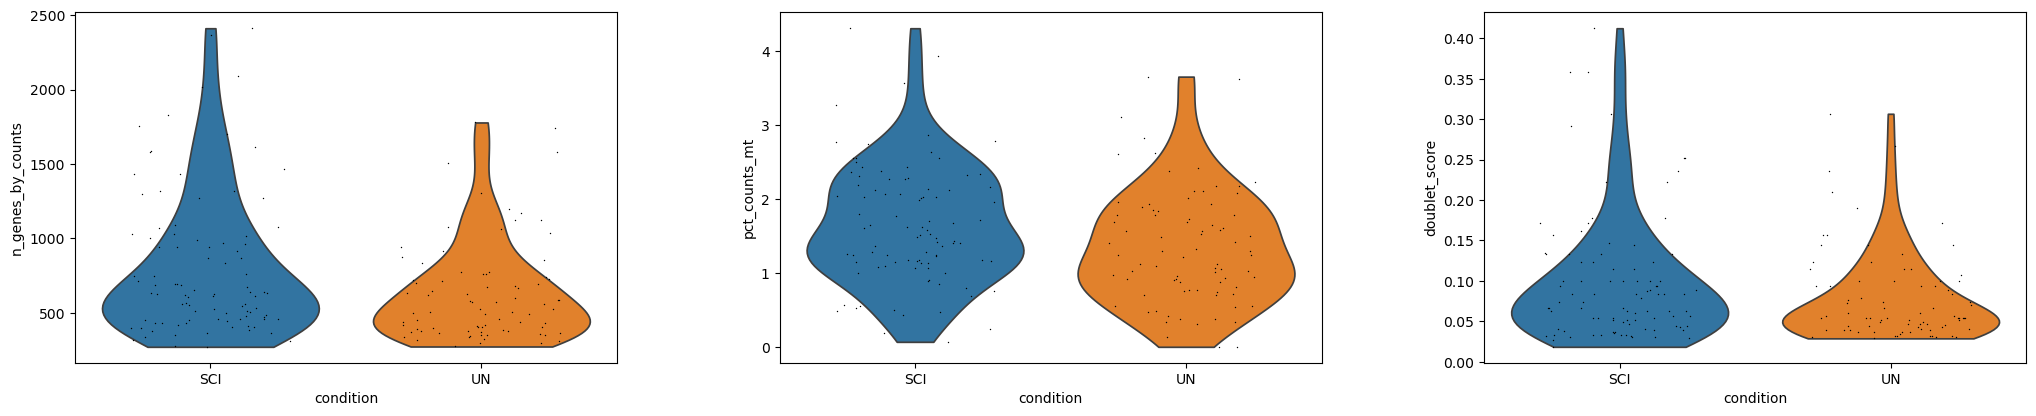

In [6]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "pct_counts_mt", "doublet_score"],
    groupby="condition",
    jitter=0.3,
    multi_panel=True,
)

In [7]:
n_before = adata.n_obs
adata = adata[~adata.obs["predicted_doublet"]].copy()
adata = adata[adata.obs["pct_counts_mt"] < 20].copy()
adata = adata[adata.obs["n_genes_by_counts"] > 200].copy()
sc.pp.filter_genes(adata, min_cells=3)
print(f"cells: {n_before} -> {adata.n_obs}")
print(f"genes retained (>=3 cells): {adata.n_vars}")

cells: 177 -> 177
genes retained (>=3 cells): 9221


This particular dataset was already well curated upstream: none of the 177
cells are dropped by the doublet / mitochondrial / gene-count filters. The
gene filter does matter, reducing the universe from 26,451 to the ~9.2k
genes detected in at least 3 cells.

In [8]:
ufrac = scat.qc.unspliced_global(adata)
print(f"global unspliced fraction: {ufrac:.1%}")

global unspliced fraction: 30.2%


~30% unspliced is a healthy value (the package warns above ~50%, which
often signals a technical issue such as poor nuclear/cytoplasmic capture).
`active_score` re-runs and records this check automatically.

## Preserve raw counts, then attach gene features

`store_raw_counts` snapshots `.X` and the spliced/unspliced layers before
any normalization, so downstream count-based backends (PyDESeq2, Memento)
and enrichment background always have access to the full, unmodified gene
set. `add_gene_features` attaches the bundled mouse gene-length /
intron-count table used for optional bias correction.

In [9]:
scat.store_raw_counts(adata, layer="counts", save_raw=False)
adata = scat.add_gene_features(adata, organism="mouse")
adata.var[["gene_length", "intron_number"]].describe()

,gene_length,intron_number
count,9221.000000,9221.000000
mean,12915.754148,10.337599
std,15536.314470,9.969041
min,69.000000,0.000000
25%,4750.000000,4.000000
50%,9072.000000,8.000000
75%,16191.000000,14.000000
max,321806.000000,145.000000


## A quick look at cell states (optional, descriptive only)

`active_score` itself works directly on `.X` plus the spliced/unspliced
layers — it does not require a UMAP or clustering. We compute one anyway,
purely to visualize how UN and SCI cells separate transcriptionally.

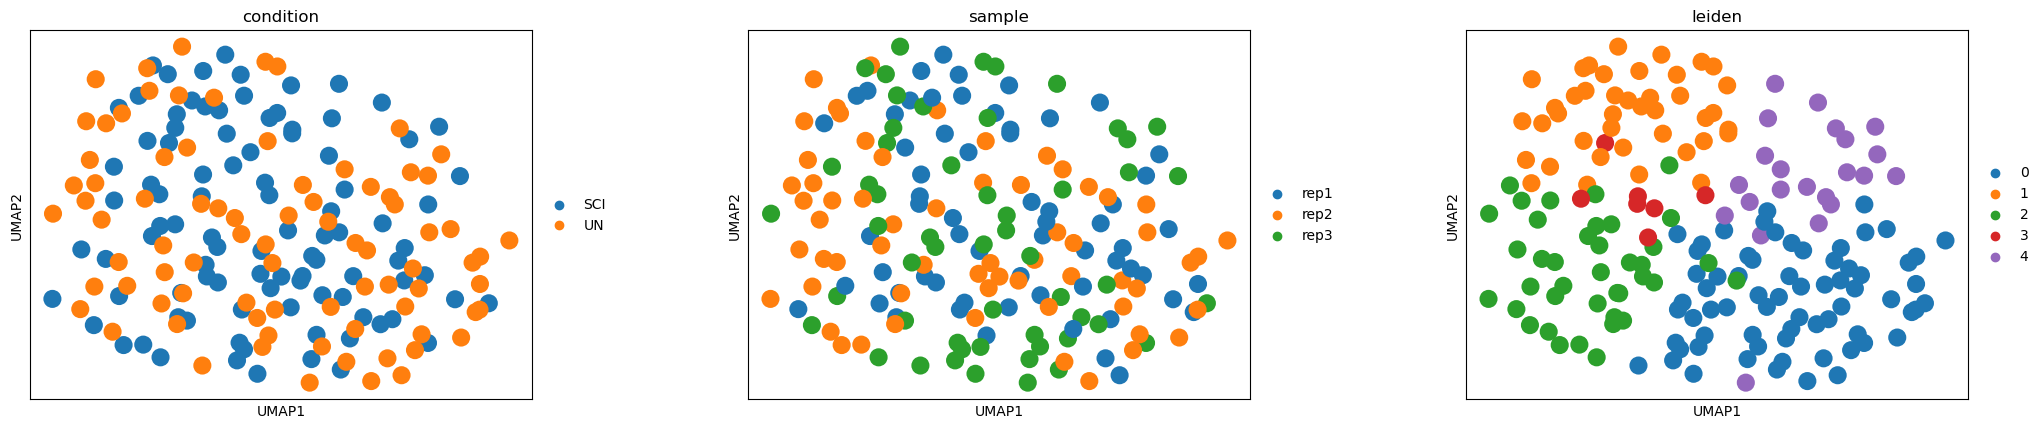

In [10]:
adata_vis = adata.copy()
sc.pp.normalize_total(adata_vis, target_sum=1e4)
sc.pp.log1p(adata_vis)
sc.pp.highly_variable_genes(adata_vis, n_top_genes=2000)
sc.pp.pca(adata_vis, use_highly_variable=True)
sc.pp.neighbors(adata_vis)
sc.tl.umap(adata_vis)
sc.tl.leiden(adata_vis, flavor="igraph", n_iterations=2)
sc.pl.umap(adata_vis, color=["condition", "sample", "leiden"], ncols=3, wspace=0.3)

## `diagnose_design`: let the package tell you what design you have

Before choosing options, run `diagnose_design`. It inspects cell counts,
sample counts, and the global unspliced fraction, and returns concrete
warnings and recommendations. It is also called automatically inside
`active_score` whenever `sample_col` or `use_pseudobulk=True` is supplied.

In [11]:
diag = scat.diagnose_design(
    adata,
    groupby="condition",
    target_group="SCI",
    reference_group="UN",
    sample_col="sample",
)

print("n_cells (SCI / UN):", diag["n_cells_target"], "/", diag["n_cells_reference"])
print("n_samples (SCI / UN):", diag["n_samples_target"], "/", diag["n_samples_reference"])
print("suggested_preset:", diag["suggested_preset"])
print("workflow_preset:", diag["workflow_preset"])
print("\nwarnings:")
for w in diag["warnings"]:
    print(" -", w)
print("\nrecommendations:")
for r in diag["recommendations"]:
    print(" -", r)

n_cells (SCI / UN): 95 / 82
n_samples (SCI / UN): 3 / 3
suggested_preset: pseudobulk
workflow_preset: pseudobulk_report

warnings:
 - Small number of biological samples per group (target=3, reference=3). Power for detecting differential nascent RNA excess will be limited. Permutation-based FDR is unreliable with so few label shuffles — prefer use_pseudobulk=True without permutation for ranking, then filter_active_genes (preset='pseudobulk') or DE p_adj for significance.

recommendations:
 - With only 3 sample(s) per group, use use_pseudobulk=True (pseudobulk_de_backend='pydeseq2') rather than use_mixed_model=True (requires >=4 samples per group).
 - After running active_score, always inspect adata.uns['scatrans']['diagnostics'] and the distributions in the returned all_results DataFrame before applying cutoffs.


With only 3 biological replicates per group, scATrans itself recommends
**pseudobulk + PyDESeq2** over a mixed model (which needs ≥4 samples/group)
and flags that permutation-based FDR will be unreliable at this sample
size. We follow that advice below, and also show what the single-cell
heuristic and permutation paths look like for comparison.

## Mode A — the one-liner: `run_default_pipeline`

For a first look, `run_default_pipeline` scores, filters, and runs GO
enrichment in a single call, auto-selecting pseudobulk when enough
replicates are present.

In [12]:
result = scat.run_default_pipeline(
    adata,
    groupby="condition",
    target_group="SCI",
    reference_group="UN",
    sample_col="sample",
    organism="mouse",
)
print("auto-selected backend:", result["backend"])
print("filter preset used:", result["filter_preset"])
print("candidates:", len(result["candidates"]))
print("enrichment:", "None (no candidates passed the strict preset)" if result["enrichment"] is None else f"{len(result['enrichment'])} terms")
result["all_results"].sort_values("active_score", ascending=False).head()[["logFC", "p_adj", "active_score"]]

auto-selected backend: {'de_method': 't-test_overestim_var', 'use_pseudobulk': True, 'sample_col': 'sample', 'pseudobulk_de_backend': 'pydeseq2'}
filter preset used: pseudobulk
candidates: 0
enrichment: None (no candidates passed the strict preset)


,logFC,p_adj,active_score
Vcam1,2.211801,0.999513,61.054032
Cobll1,1.093613,0.999513,59.494934
Tmeff2,1.194336,0.999513,58.849826
Pitpnc1,1.018072,0.999513,58.295126
Plcl1,0.962131,0.999513,57.720715


`run_default_pipeline` auto-selected pseudobulk + PyDESeq2 (because
`sample_col` was supplied with 3 replicates/group) and the matching
`filter_preset="pseudobulk"` — the same honest result as the manual walk-through
below: at `p_adj < 0.05` on a 3-vs-3 design, **zero genes** pass, so
`candidates` is empty and `enrichment` is `None` (there is nothing to
enrich). This is expected, not an error — see Mode C for the
exploratory-candidate workaround and a full explanation.

## Mode B — manual, single-cell heuristic

`active_score` with its defaults runs differential expression per cell
(not per pseudobulk sample) and computes the unspliced-excess term directly
on single cells.

In [13]:
adata_res, significant, all_results = scat.active_score(
    adata_input=adata,
    groupby="condition",
    target_group="SCI",
    reference_group="UN",
    de_method="wilcoxon",
    show_plot=False,
)
all_results.sort_values("active_score", ascending=False).head(8)[
    ["logFC", "p_adj", "unspliced_excess_residual", "active_score"]
]

,logFC,p_adj,unspliced_excess_residual,active_score
Prkg1,26.726971,0.994983,1.405985,66.727460
Plcl1,27.793922,0.994983,0.782229,66.335979
Samd12,26.600834,0.994983,0.602810,65.628986
Nxn,28.116873,0.994983,0.447306,64.068850
Trpm3,2.930032,0.994983,1.073485,63.555366
Gphn,26.220245,0.994983,0.378836,62.809228
Mecom,2.117509,0.994983,1.124947,60.682844
Cobll1,1.730982,0.994983,0.736788,58.014759


:::{note}
Notice the extreme `logFC` values (~26-28) on a few genes (e.g. `Prkg1`,
`Plcl1`, `Nxn`). This is a well-known artifact of scanpy's
`rank_genes_groups` log-fold-change estimator when a gene is expressed in
very few cells near zero in one group — not evidence of a huge biological
effect. `active_score`'s composite ranking is somewhat robust to this
because logFC is only one of three ingredients, but always sanity-check
individual genes against raw counts (e.g. with `velocity_phase_portraits`
below) before reporting them. See {doc}`../statistical_guidance`.
:::

In [14]:
print("heuristic-preset candidates:", len(scat.filter_active_genes(all_results, preset="heuristic")))
print("min p_adj across all genes:", all_results["p_adj"].min())

heuristic-preset candidates: 0
min p_adj across all genes: 0.9949828702539322


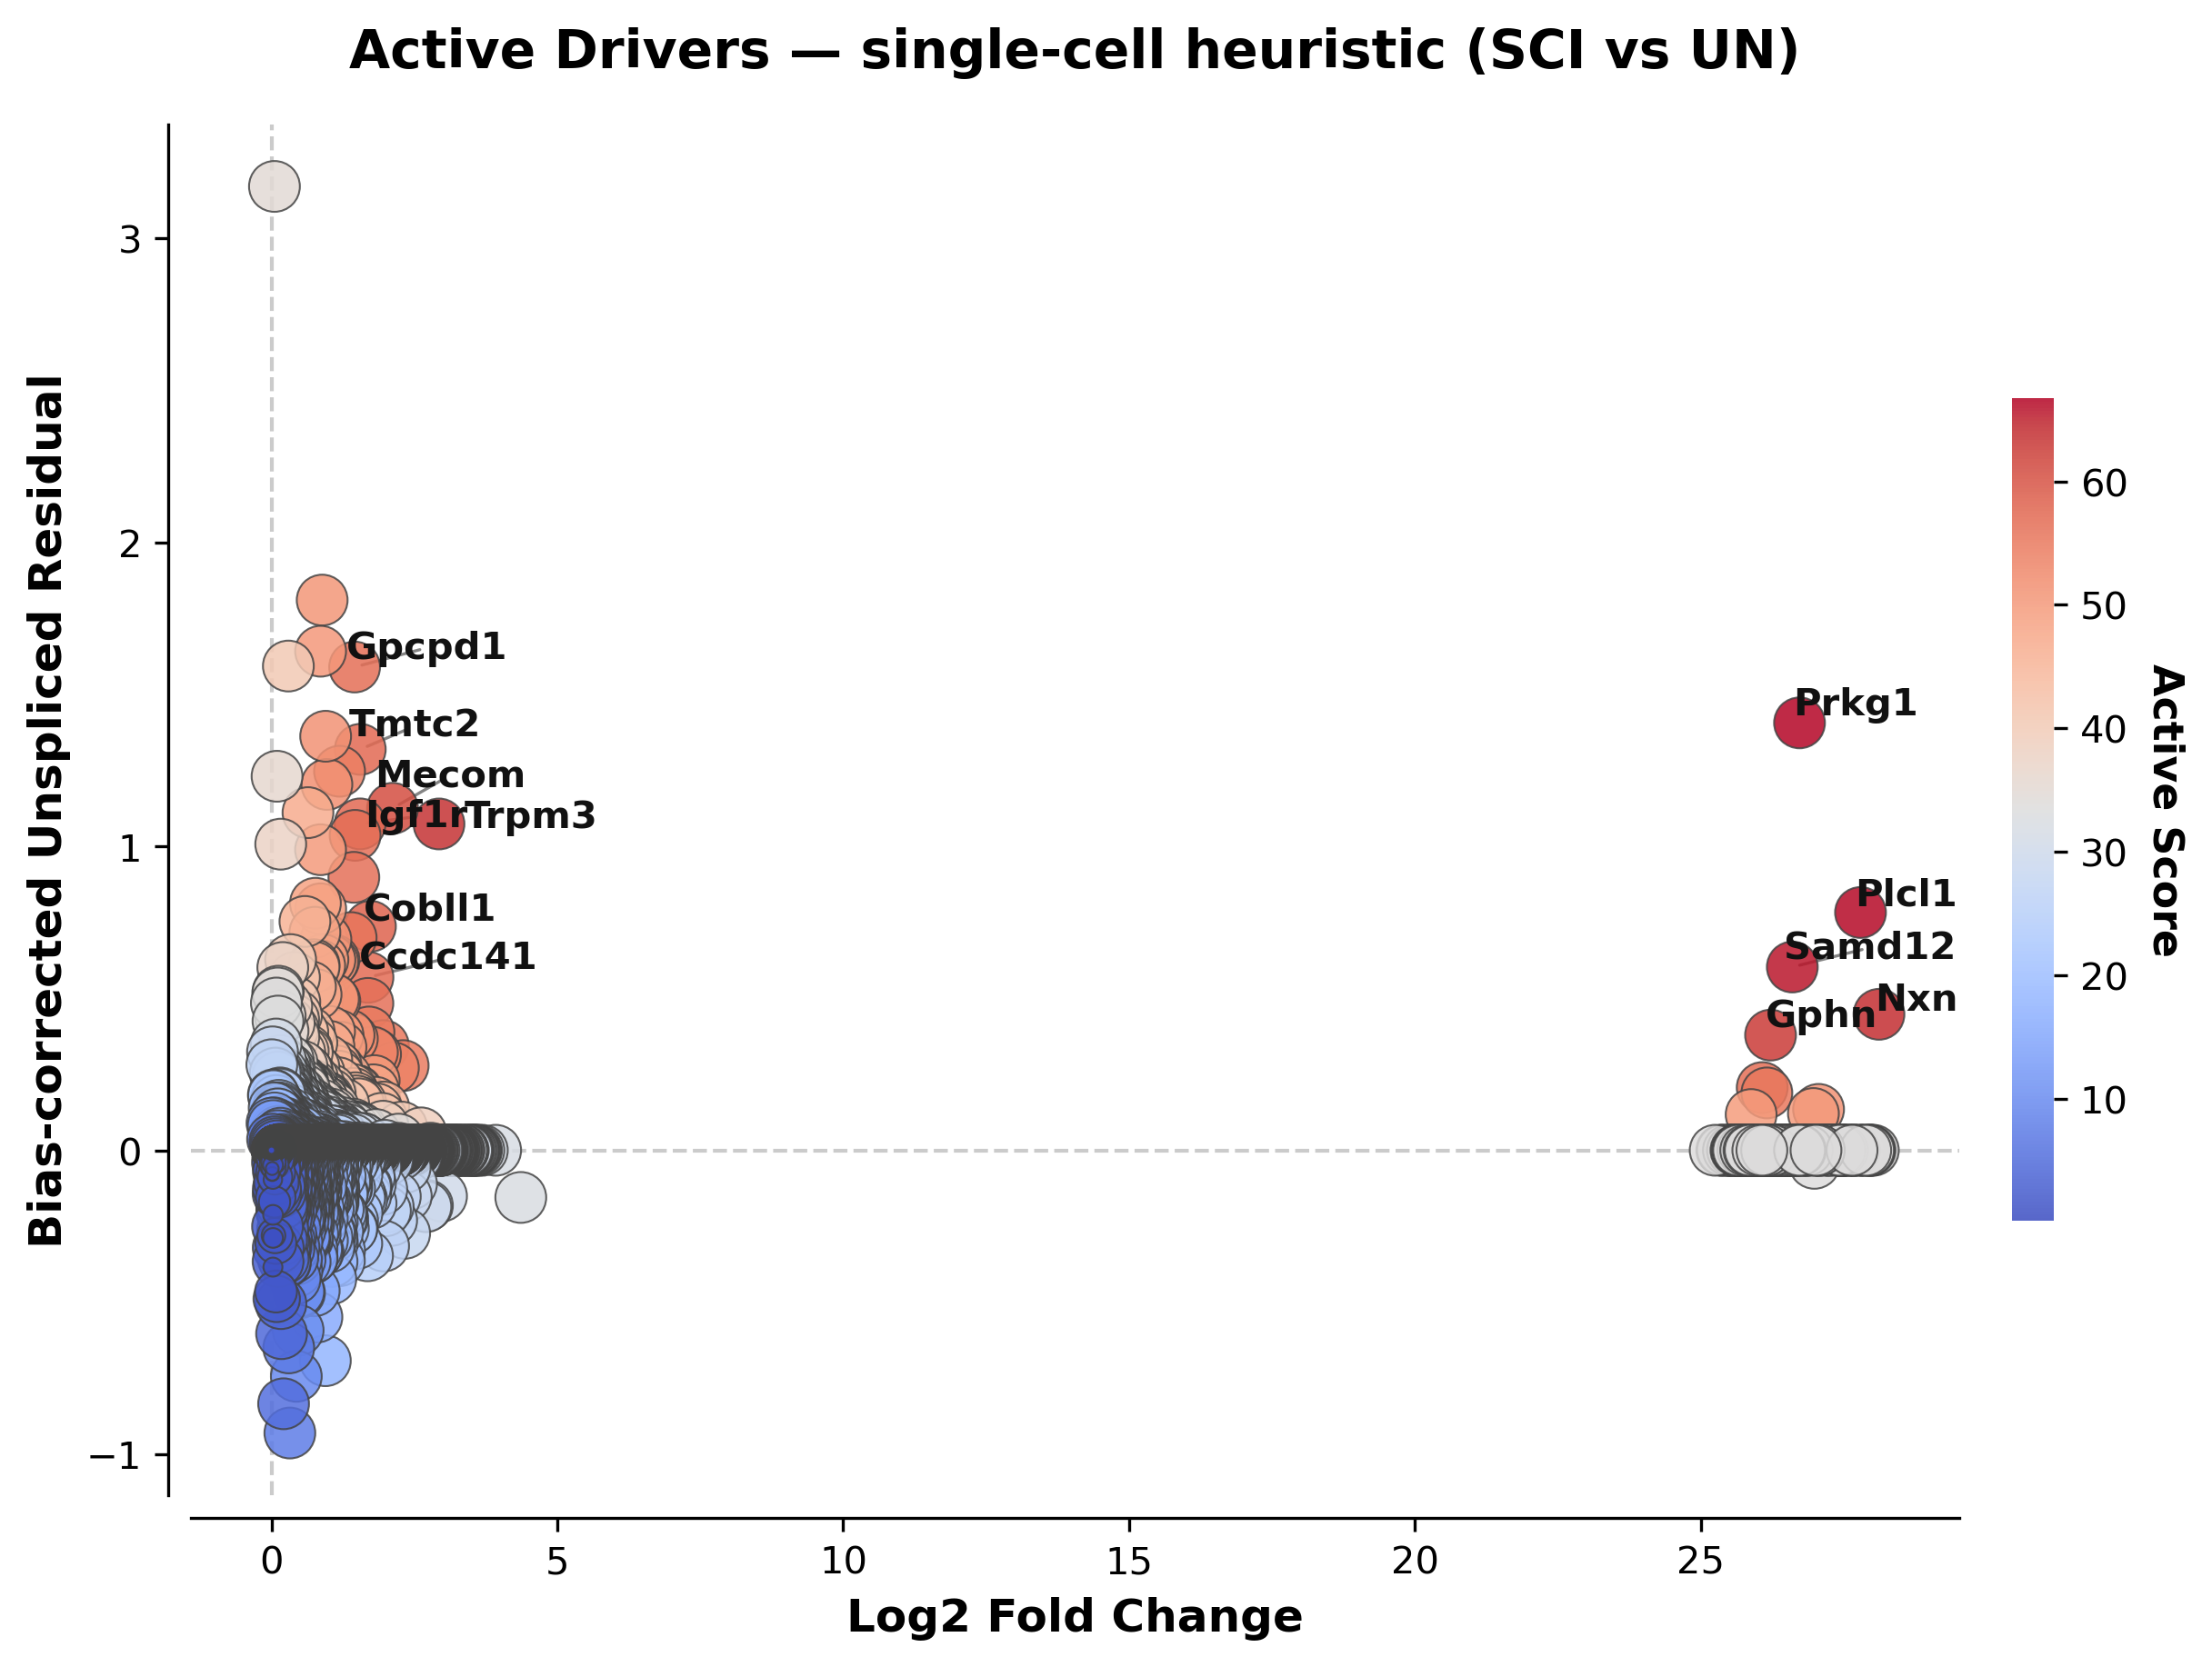

(<Figure size 2400x1800 with 2 Axes>,
 <Axes: title={'center': 'Active Drivers — single-cell heuristic (SCI vs UN)'}, xlabel='Log2 Fold Change', ylabel='Bias-corrected Unspliced Residual'>)

In [15]:
scat.pl.comet_plot(all_results, top_n=12, title="Active Drivers — single-cell heuristic (SCI vs UN)")

## Mode C — pseudobulk + PyDESeq2 (the recommended path here)

This aggregates cells into one pseudobulk profile per (condition, sample)
and runs PyDESeq2 — the design `diagnose_design` recommended above.

In [16]:
adata_res_pb, significant_pb, all_results_pb = scat.active_score(
    adata_input=adata,
    groupby="condition",
    target_group="SCI",
    reference_group="UN",
    use_pseudobulk=True,
    sample_col="sample",
    pseudobulk_de_backend="pydeseq2",
    show_plot=False,
)
all_results_pb.sort_values("active_score", ascending=False).head(10)[
    ["logFC", "p_adj", "unspliced_excess_residual", "active_score"]
]

,logFC,p_adj,unspliced_excess_residual,active_score
Vcam1,2.211801,0.999513,7.739810,61.054032
Cobll1,1.093613,0.999513,23.042433,59.494934
Tmeff2,1.194336,0.999513,11.158579,58.849826
Pitpnc1,1.018072,0.999513,15.865926,58.295126
Plcl1,0.962131,0.999513,16.528507,57.720715
Igf1r,0.899307,0.999513,31.005419,57.308573
Zfp366,1.159273,0.999513,8.128796,56.450931
Mecom,0.866779,0.999513,14.552282,56.212011
Tjp1,0.807648,0.999513,16.418442,55.620784
Rapgef5,0.989955,0.999513,9.047048,55.518645


In [17]:
print("min p_adj (pseudobulk DESeq2):", all_results_pb["p_adj"].min())
print("preset='pseudobulk' candidates:", len(scat.filter_active_genes(all_results_pb, preset="pseudobulk")))
print("built-in `significant` list:", len(significant_pb))

min p_adj (pseudobulk DESeq2): 0.5584481513291821
preset='pseudobulk' candidates: 0
built-in `significant` list: 0


:::{note}
With only 3 vs. 3 pseudobulk samples, **no gene clears `p_adj < 0.05`**
here (minimum adjusted p-value ≈ 0.56) — the built-in `significant` list
and the strict `preset="pseudobulk"` filter are both legitimately empty.
This is real, honest low-power biology, not a bug: three replicates per
group is thin for genome-wide multiple testing correction. The right move
is **not** to lower the threshold until something turns up, but to treat
`active_score` as a ranking/hypothesis-generating tool and say so plainly
in any write-up — see {doc}`../statistical_guidance`.
:::

In [18]:
# Exploratory ranking: effect size + active_score, p-value gate relaxed
# (this is a *ranked candidate list* for hypothesis generation, not a
# p<0.05 confirmatory claim — see the note above).
candidates = scat.filter_active_genes(
    all_results_pb,
    active_score_cutoff=40,
    logfc_cutoff=0.5,
    pval_cutoff=1.0,
)
print("exploratory candidates:", len(candidates))
candidates.sort_values("active_score", ascending=False).head(10)[
    ["logFC", "p_adj", "unspliced_excess_residual", "active_score"]
]

exploratory candidates: 64


,logFC,p_adj,unspliced_excess_residual,active_score
Vcam1,2.211801,0.999513,7.739810,61.054032
Cobll1,1.093613,0.999513,23.042433,59.494934
Tmeff2,1.194336,0.999513,11.158579,58.849826
Pitpnc1,1.018072,0.999513,15.865926,58.295126
Plcl1,0.962131,0.999513,16.528507,57.720715
Igf1r,0.899307,0.999513,31.005419,57.308573
Zfp366,1.159273,0.999513,8.128796,56.450931
Mecom,0.866779,0.999513,14.552282,56.212011
Tjp1,0.807648,0.999513,16.418442,55.620784
Rapgef5,0.989955,0.999513,9.047048,55.518645


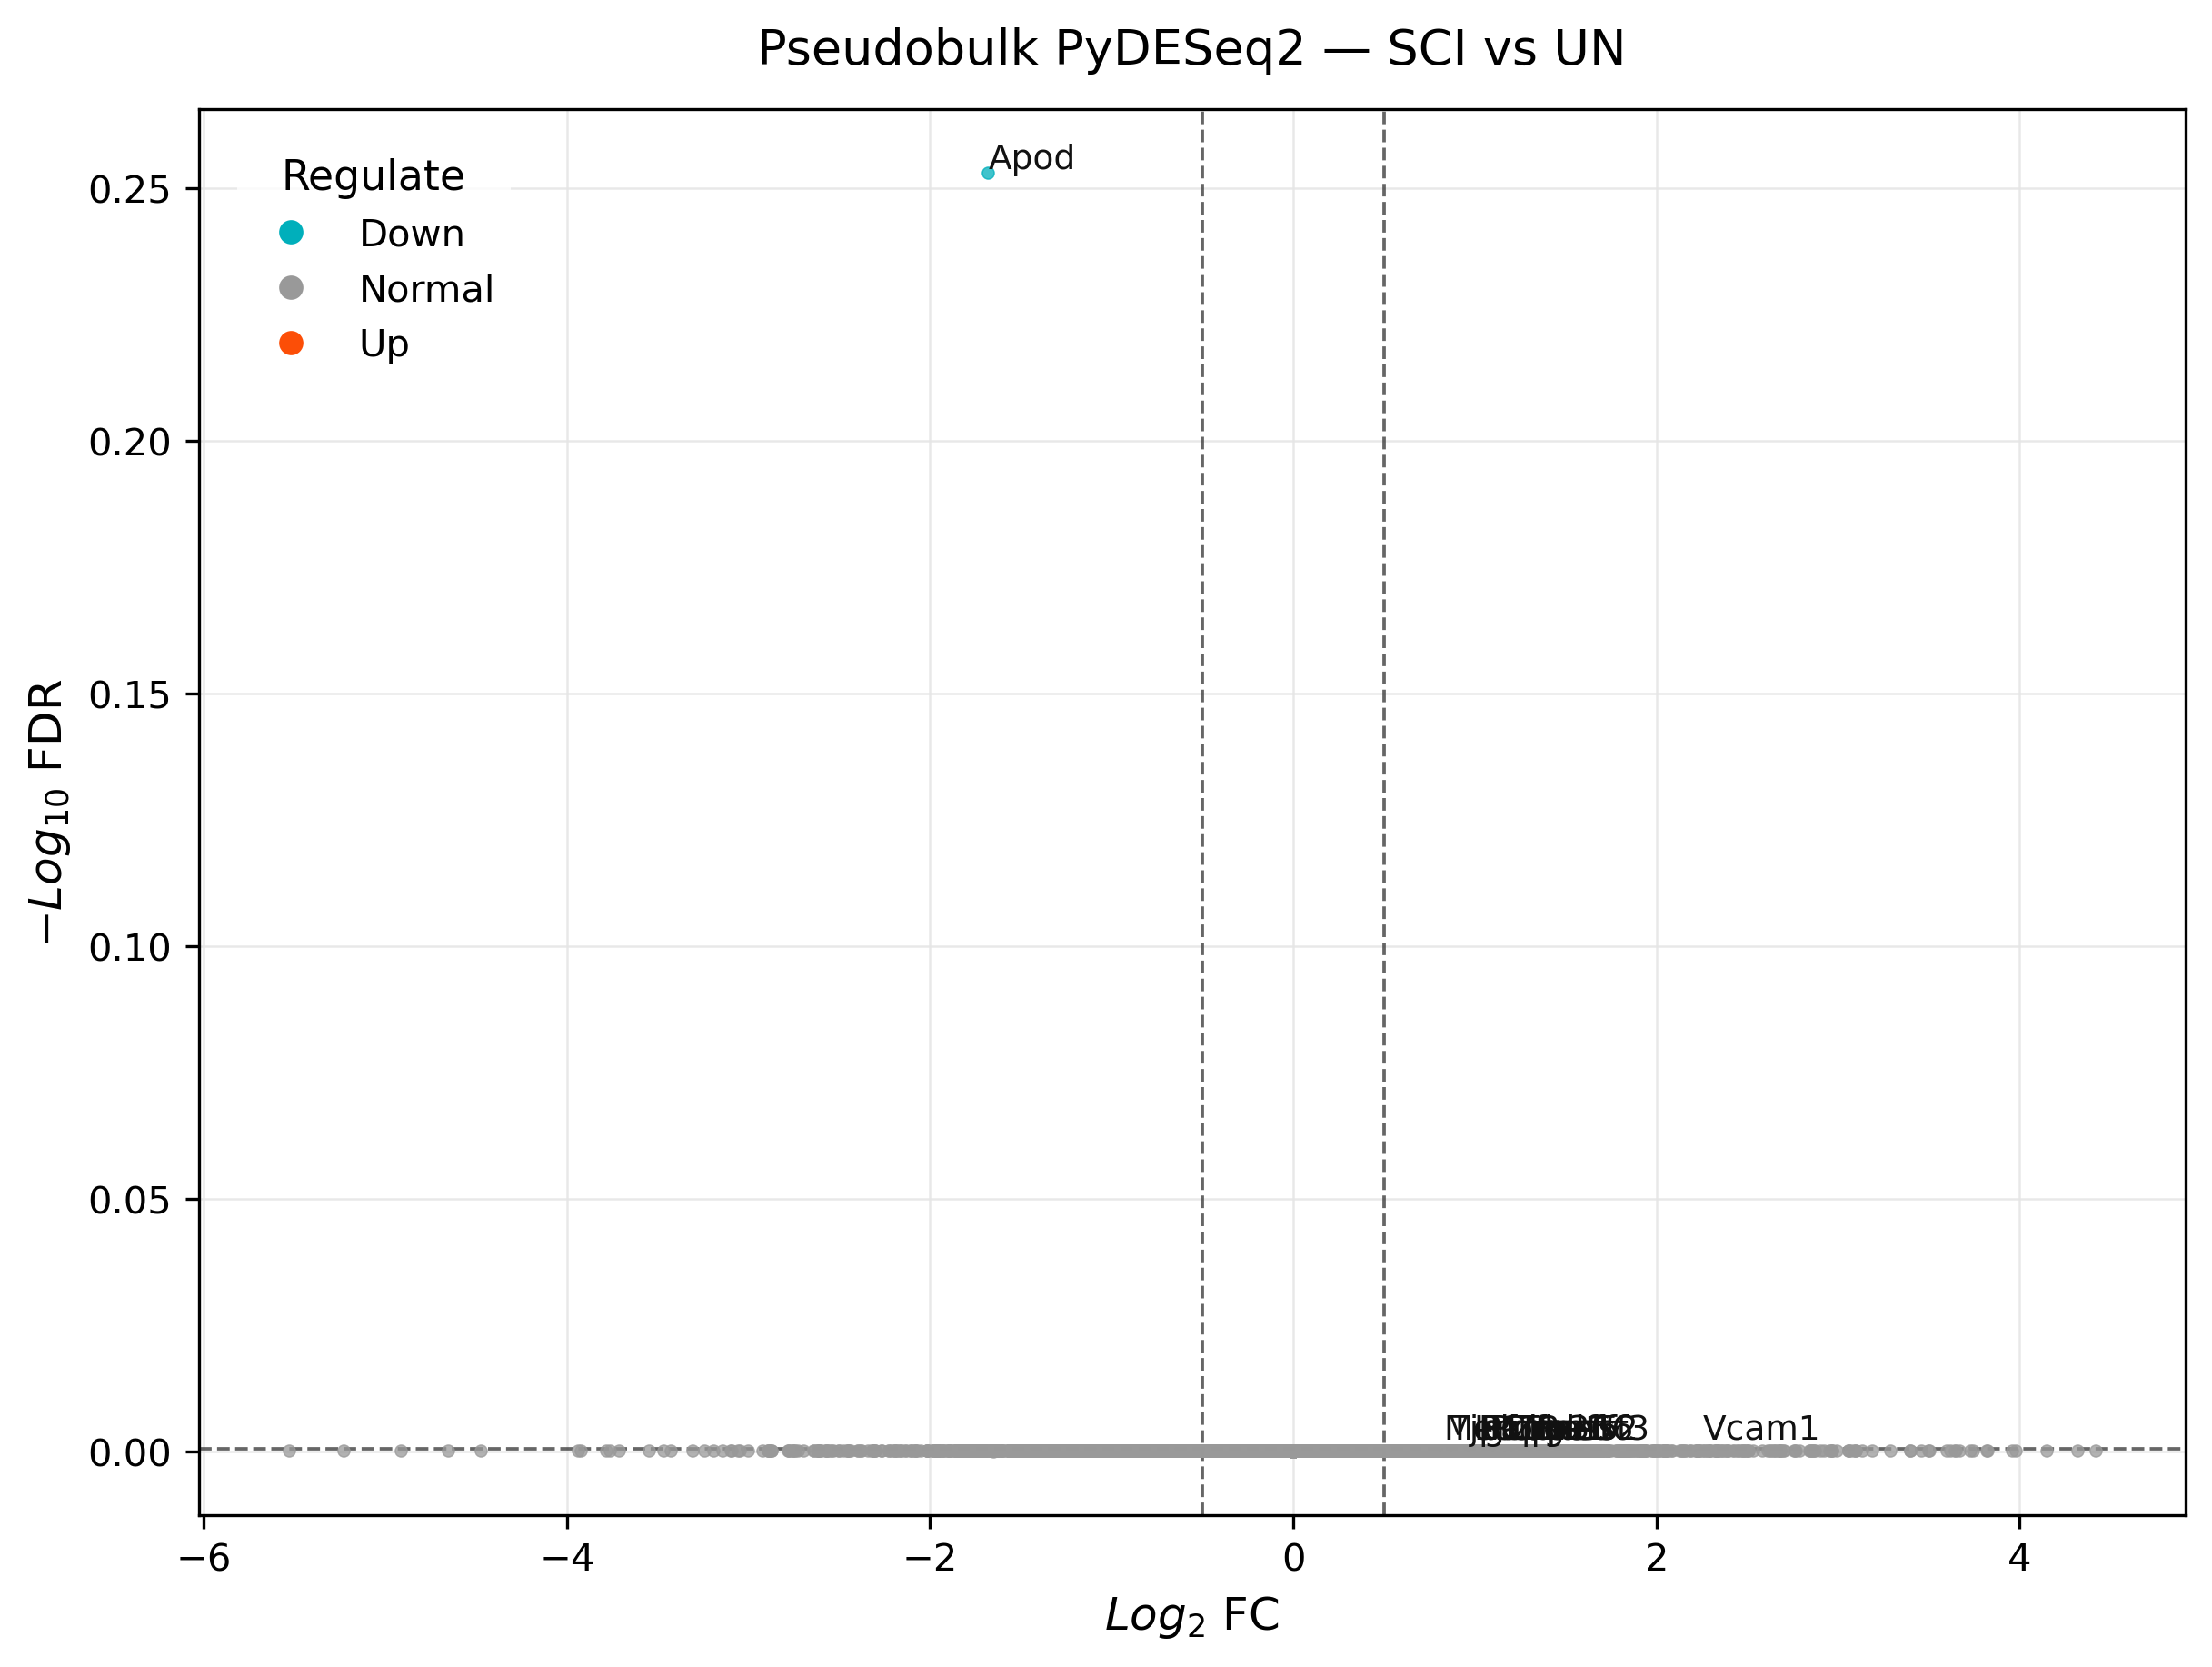

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: title={'center': 'Pseudobulk PyDESeq2 — SCI vs UN'}, xlabel='$Log_2$ FC', ylabel='$-Log_{10}$ FDR'>)

In [19]:
scat.pl.volcano_plot(
    all_results_pb,
    style="ggvolcano",
    top_n=12,
    logfc_cutoff=0.5,
    pval_cutoff=0.999,  # relaxed to match the exploratory cutoff above (p_adj min here is ~0.56)
    title="Pseudobulk PyDESeq2 — SCI vs UN",
)

## Mode D — permutation-based FDR (single-cell path)

`diagnose_design` already warned that permutation is unreliable with only
3 samples/group in *pseudobulk* mode. We instead demonstrate the mechanism
on the single-cell heuristic path with a modest `n_perm` and the fast
backend, purely to show how it works — the conclusion is consistent with
everything above: still no significant genes at this sample size.

In [20]:
adata_res_perm, significant_perm, all_results_perm = scat.active_score(
    adata_input=adata,
    groupby="condition",
    target_group="SCI",
    reference_group="UN",
    use_permutation=True,
    n_perm=100,
    perm_de_backend="fast",  # exploratory speed; use "same" for manuscript-quality FDR
    show_plot=False,
)
print("significant (permutation FDR):", len(significant_perm))
print(adata_res_perm.uns["scatrans"].get("permutation_approximation_note"))
all_results_perm.sort_values("active_score", ascending=False).head(5)[
    ["logFC", "p_adj", "unspliced_excess_fdr", "active_score"]
]

significant (permutation FDR): 0
For efficiency, unspliced/spliced layers and reference gamma are fixed from the original data. Group labels are shuffled to recompute DE, unspliced excess residual, composite active_score, and unspliced_excess permutation p-values.


,logFC,p_adj,unspliced_excess_fdr,active_score
Plcl1,27.793922,0.498326,0.999048,74.963961
Nxn,28.116873,0.456581,1.000000,73.615214
Prkg1,26.726971,0.587123,0.706809,73.537238
Igf1r,1.549713,0.212572,0.501937,73.407025
Mecom,2.117509,0.347586,0.632578,72.878279


## Mode E — reference-gamma robustness and bias-correction diagnostics

`gamma_method="empirical_bayes"` shrinks each gene's reference U/S ratio
toward a shared, hierarchically-estimated prior — a more robust option when
the reference group is small. `show_effective_gamma=True` exposes the
per-gene shrunk gamma so its behavior can be inspected directly.

In [21]:
adata_res_gb, _, all_results_gb = scat.active_score(
    adata_input=adata,
    groupby="condition",
    target_group="SCI",
    reference_group="UN",
    gamma_method="empirical_bayes",
    show_effective_gamma=True,
    show_plot=False,
)
v = adata_res_gb.uns["scatrans"]["diagnostics"]["velocity"]
print("gamma_prior_mean:", v.get("gamma_prior_mean"))
print("shrinkage_summary:", v.get("shrinkage_summary"))

gamma_prior_mean: -2.1783053057222053
shrinkage_summary: {'mean': 0.9630662745530777, 'q10': 0.94207253767107, 'q25': 0.9508108342897064, 'q50': 0.9590140129606987, 'q75': 0.9786133392259676, 'q90': 0.9873976599591713}


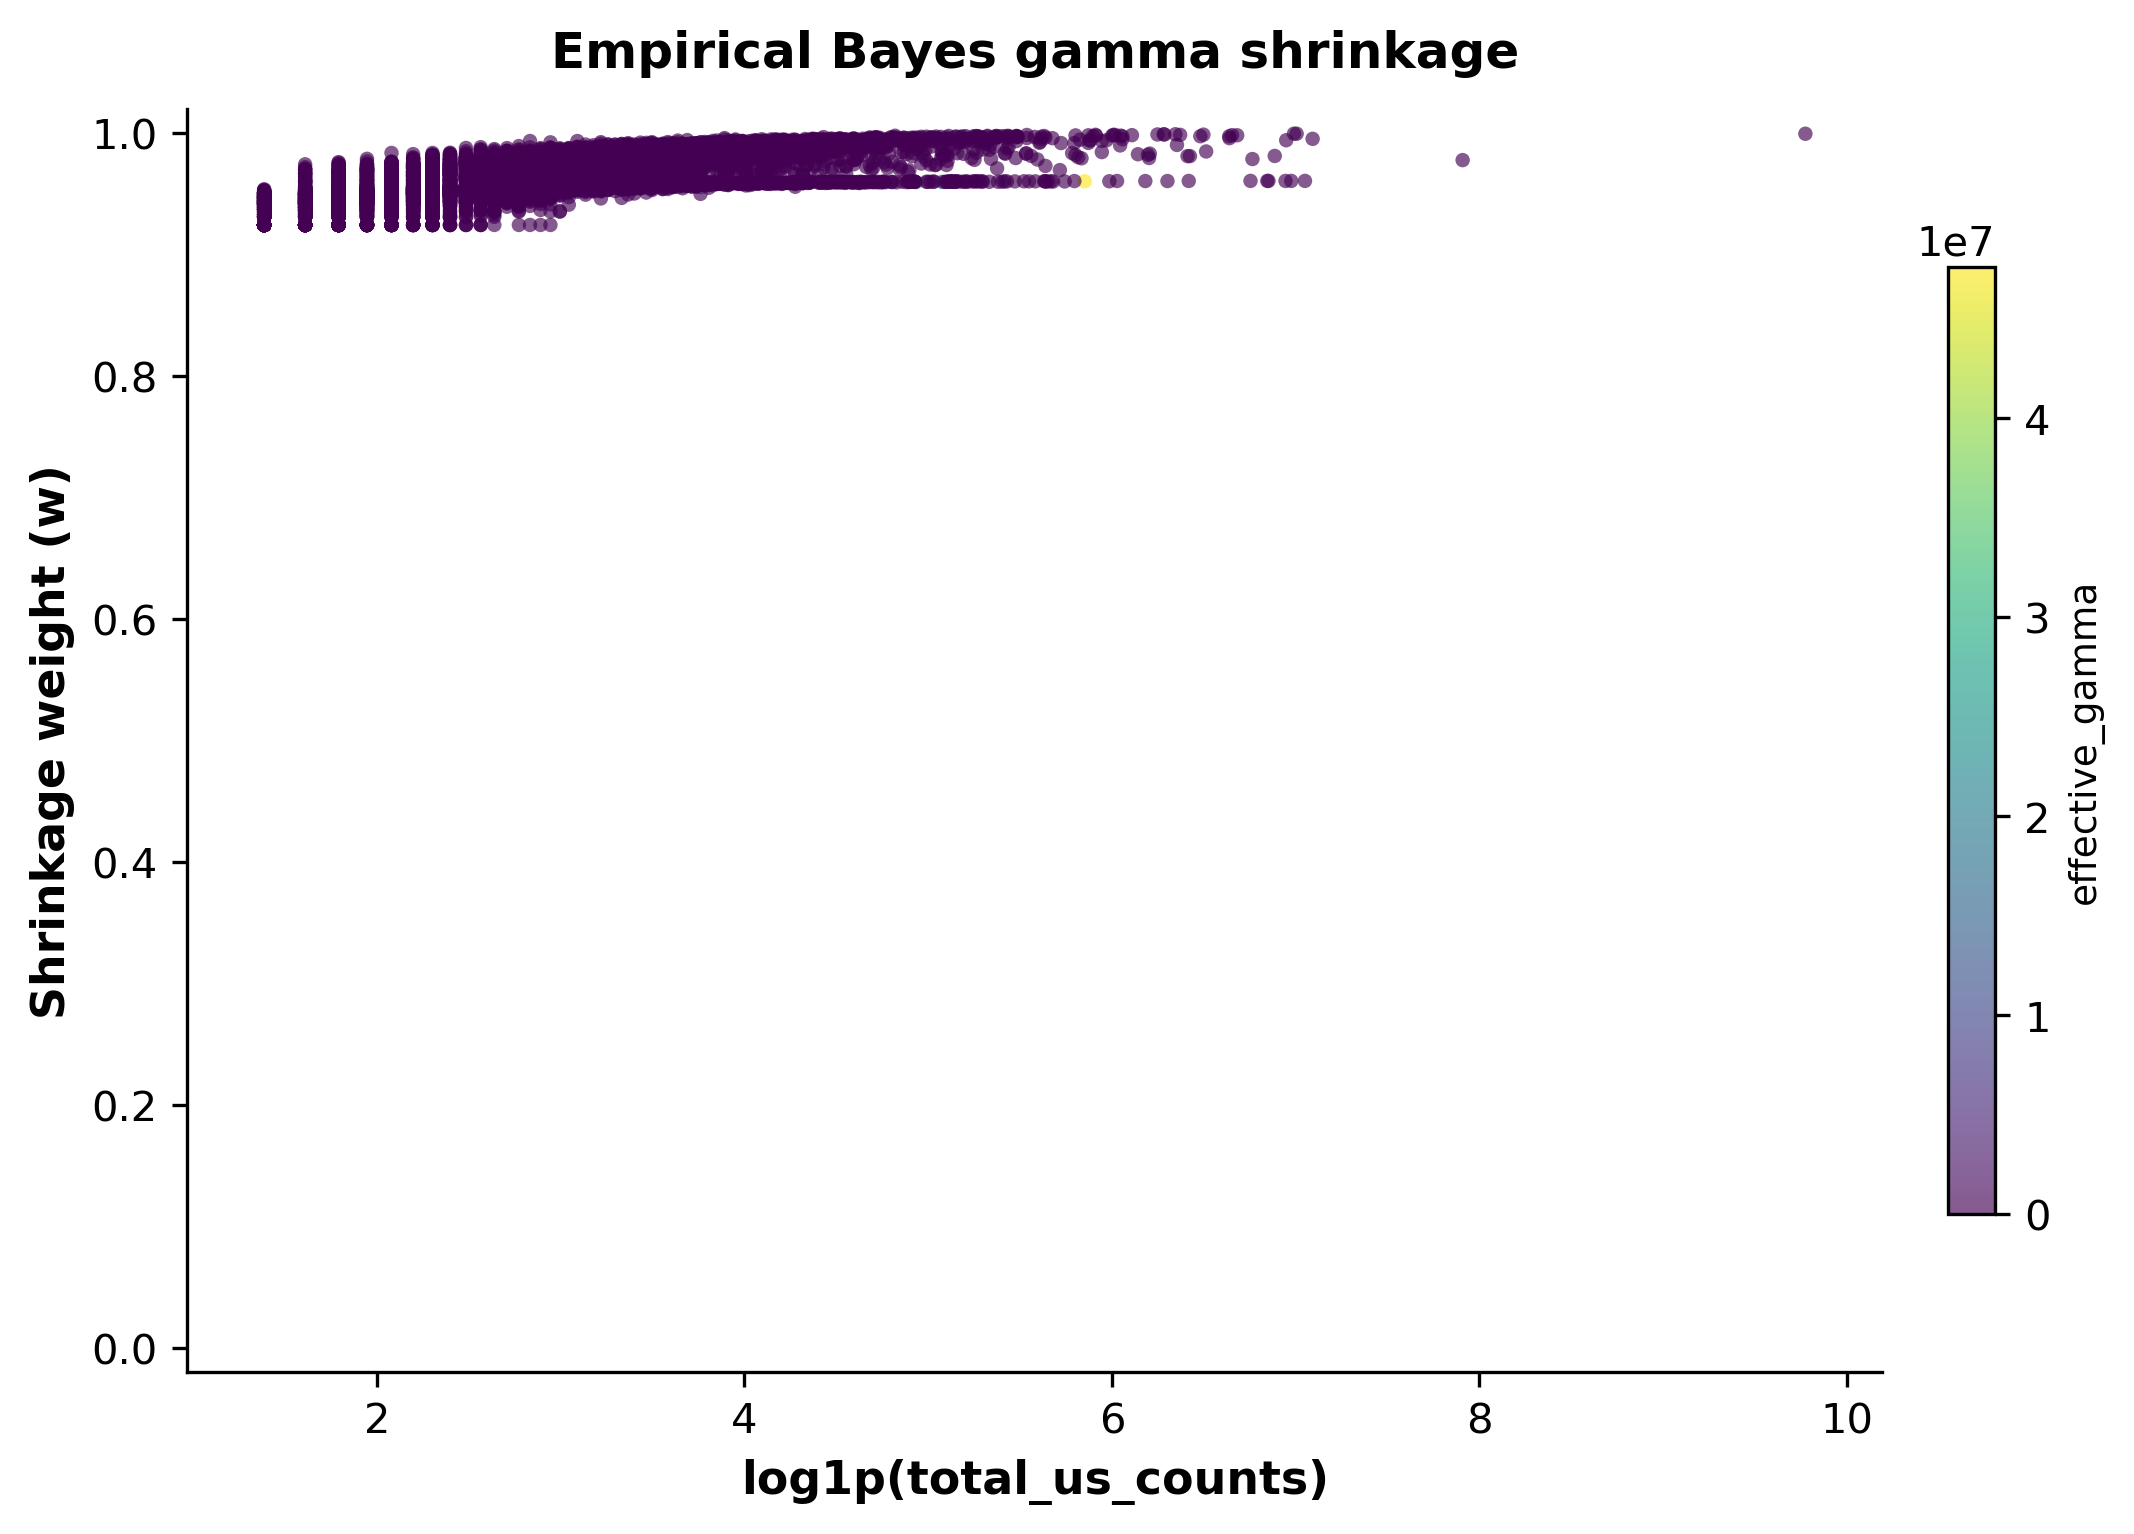

(<Figure size 2100x1500 with 2 Axes>,
 <Axes: title={'center': 'Empirical Bayes gamma shrinkage'}, xlabel='log1p(total_us_counts)', ylabel='Shrinkage weight (w)'>)

In [22]:
scat.pl.gamma_shrinkage_plot(all_results_gb)

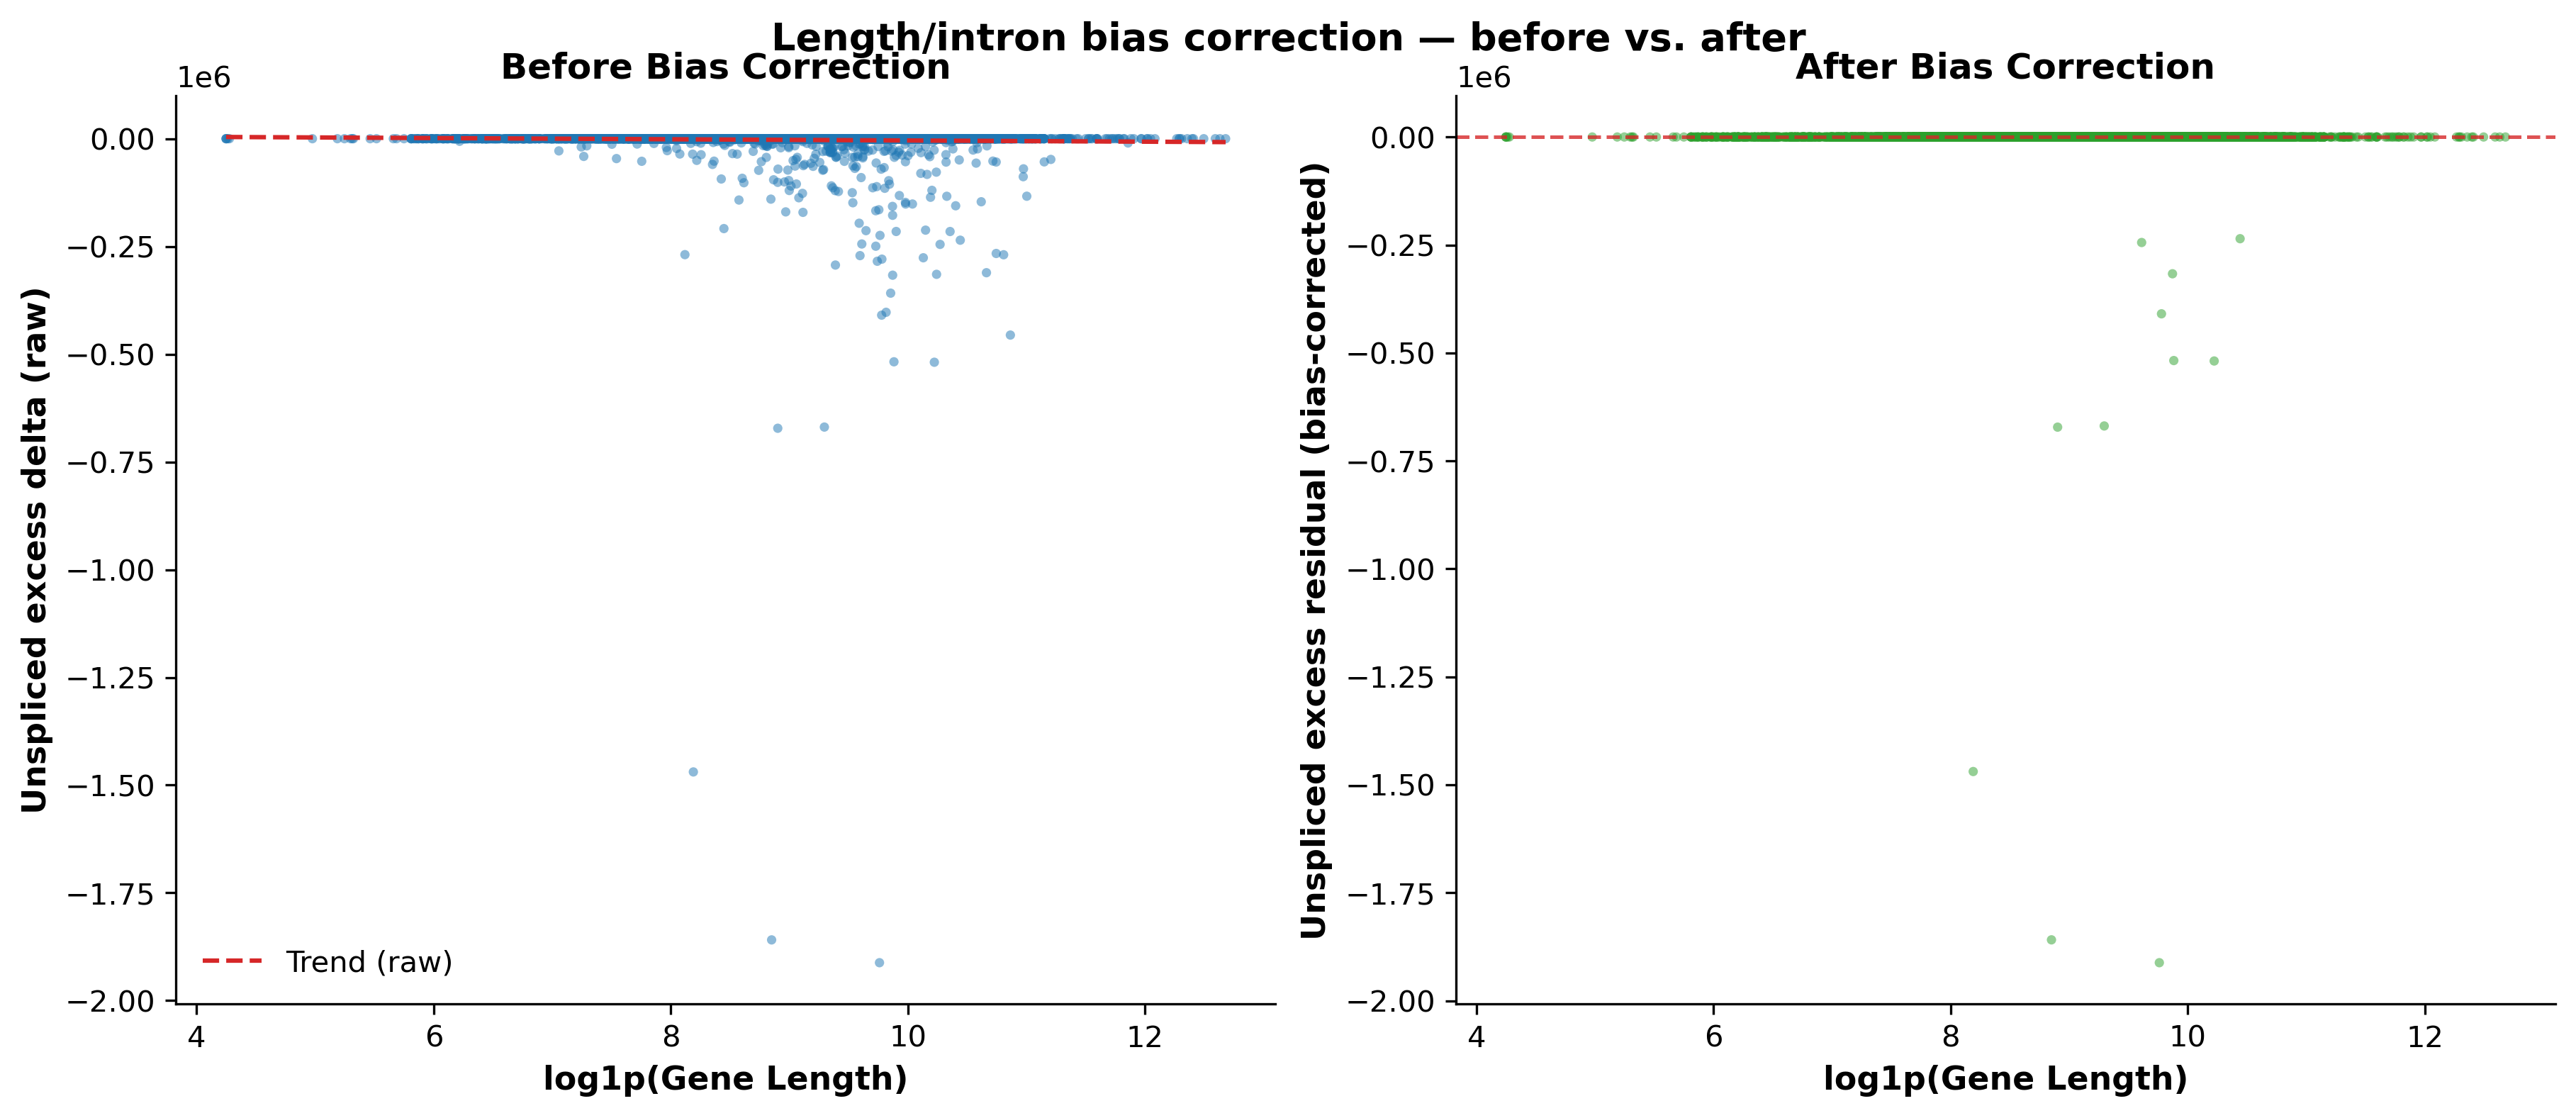

(<Figure size 3600x1500 with 2 Axes>,
 array([<Axes: title={'center': 'Before Bias Correction'}, xlabel='log1p(Gene Length)', ylabel='Unspliced excess delta (raw)'>,
        <Axes: title={'center': 'After Bias Correction'}, xlabel='log1p(Gene Length)', ylabel='Unspliced excess residual (bias-corrected)'>],
       dtype=object))

In [23]:
scat.pl.bias_diagnostic_plot(all_results_gb, title="Length/intron bias correction — before vs. after")

## Mode F — advanced mode (scVelo moments smoothing)

`mode="advanced"` uses scVelo's moments (kNN-smoothed spliced/unspliced
means) before computing the group-wise gamma delta, instead of the raw
per-cell counts. It is still a reference-gamma excess calculation, not a
full dynamical velocity model — just computed on smoothed rather than raw
values. Requires `pip install "scatrans[advanced]"`.

In [24]:
adata_res_adv, _, all_results_adv = scat.active_score(
    adata_input=adata,
    groupby="condition",
    target_group="SCI",
    reference_group="UN",
    mode="advanced",
    show_plot=False,
)
all_results_adv.sort_values("active_score", ascending=False).head(5)[
    ["logFC", "p_adj", "active_score"]
]

computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


,logFC,p_adj,active_score
Plcl1,27.793922,0.498326,74.586539
Prkg1,26.726971,0.587123,73.507546
Nxn,28.116873,0.456581,73.222538
Mecom,2.117509,0.347586,72.813430
Igf1r,1.549713,0.212572,72.749187


## Closing the loop: one enrichment pass

Functional enrichment is covered in full in the companion tutorial,
{doc}`t_ec_standalone_de_enrichment` (ORA, KEGG, GO all-ontology, GSEA,
redundancy reduction, and the full plotting gallery). Here we just run one
GO Biological Process over-representation test on the pseudobulk
exploratory candidates from Mode C, to close the workflow end to end.

In [25]:
enrich_res = scat.run_enrichment(
    gene_list=candidates.index.tolist(),
    gene_sets="GO_Biological_Process",
    organism="mouse",
    adata=adata,          # uses the full stored gene set (from store_raw_counts) as background
    pval_cutoff=1.0,       # relaxed, consistent with the exploratory candidate list above
)
print(enrich_res.shape)
enrich_res.sort_values("pvalue").head(10)[["Term", "Overlap", "pvalue", "p.adjust"]]

(13, 15)


,Term,Overlap,pvalue,p.adjust
4,adherens junction organization (GO:0034332),4/33,0.000094,0.629774
0,regulation of synapse organization (GO:0050807),8/253,0.000505,0.629774
2,protein localization to adherens junction (GO:...,2/5,0.000530,0.629774
5,cell junction assembly (GO:0034329),9/321,0.000531,0.629774
3,regulation of cell junction assembly (GO:1901888),7/195,0.000548,0.629774
1,regulation of synapse structure or activity (G...,8/257,0.000560,0.629774
6,regulation of hormone metabolic process (GO:00...,3/25,0.000788,0.742972
8,cellular response to amyloid-beta (GO:1904646),3/26,0.000886,0.742972
7,response to amyloid-beta (GO:1904645),3/27,0.000992,0.742972
9,bile acid and bile salt transport (GO:0015721),2/7,0.001103,0.743692


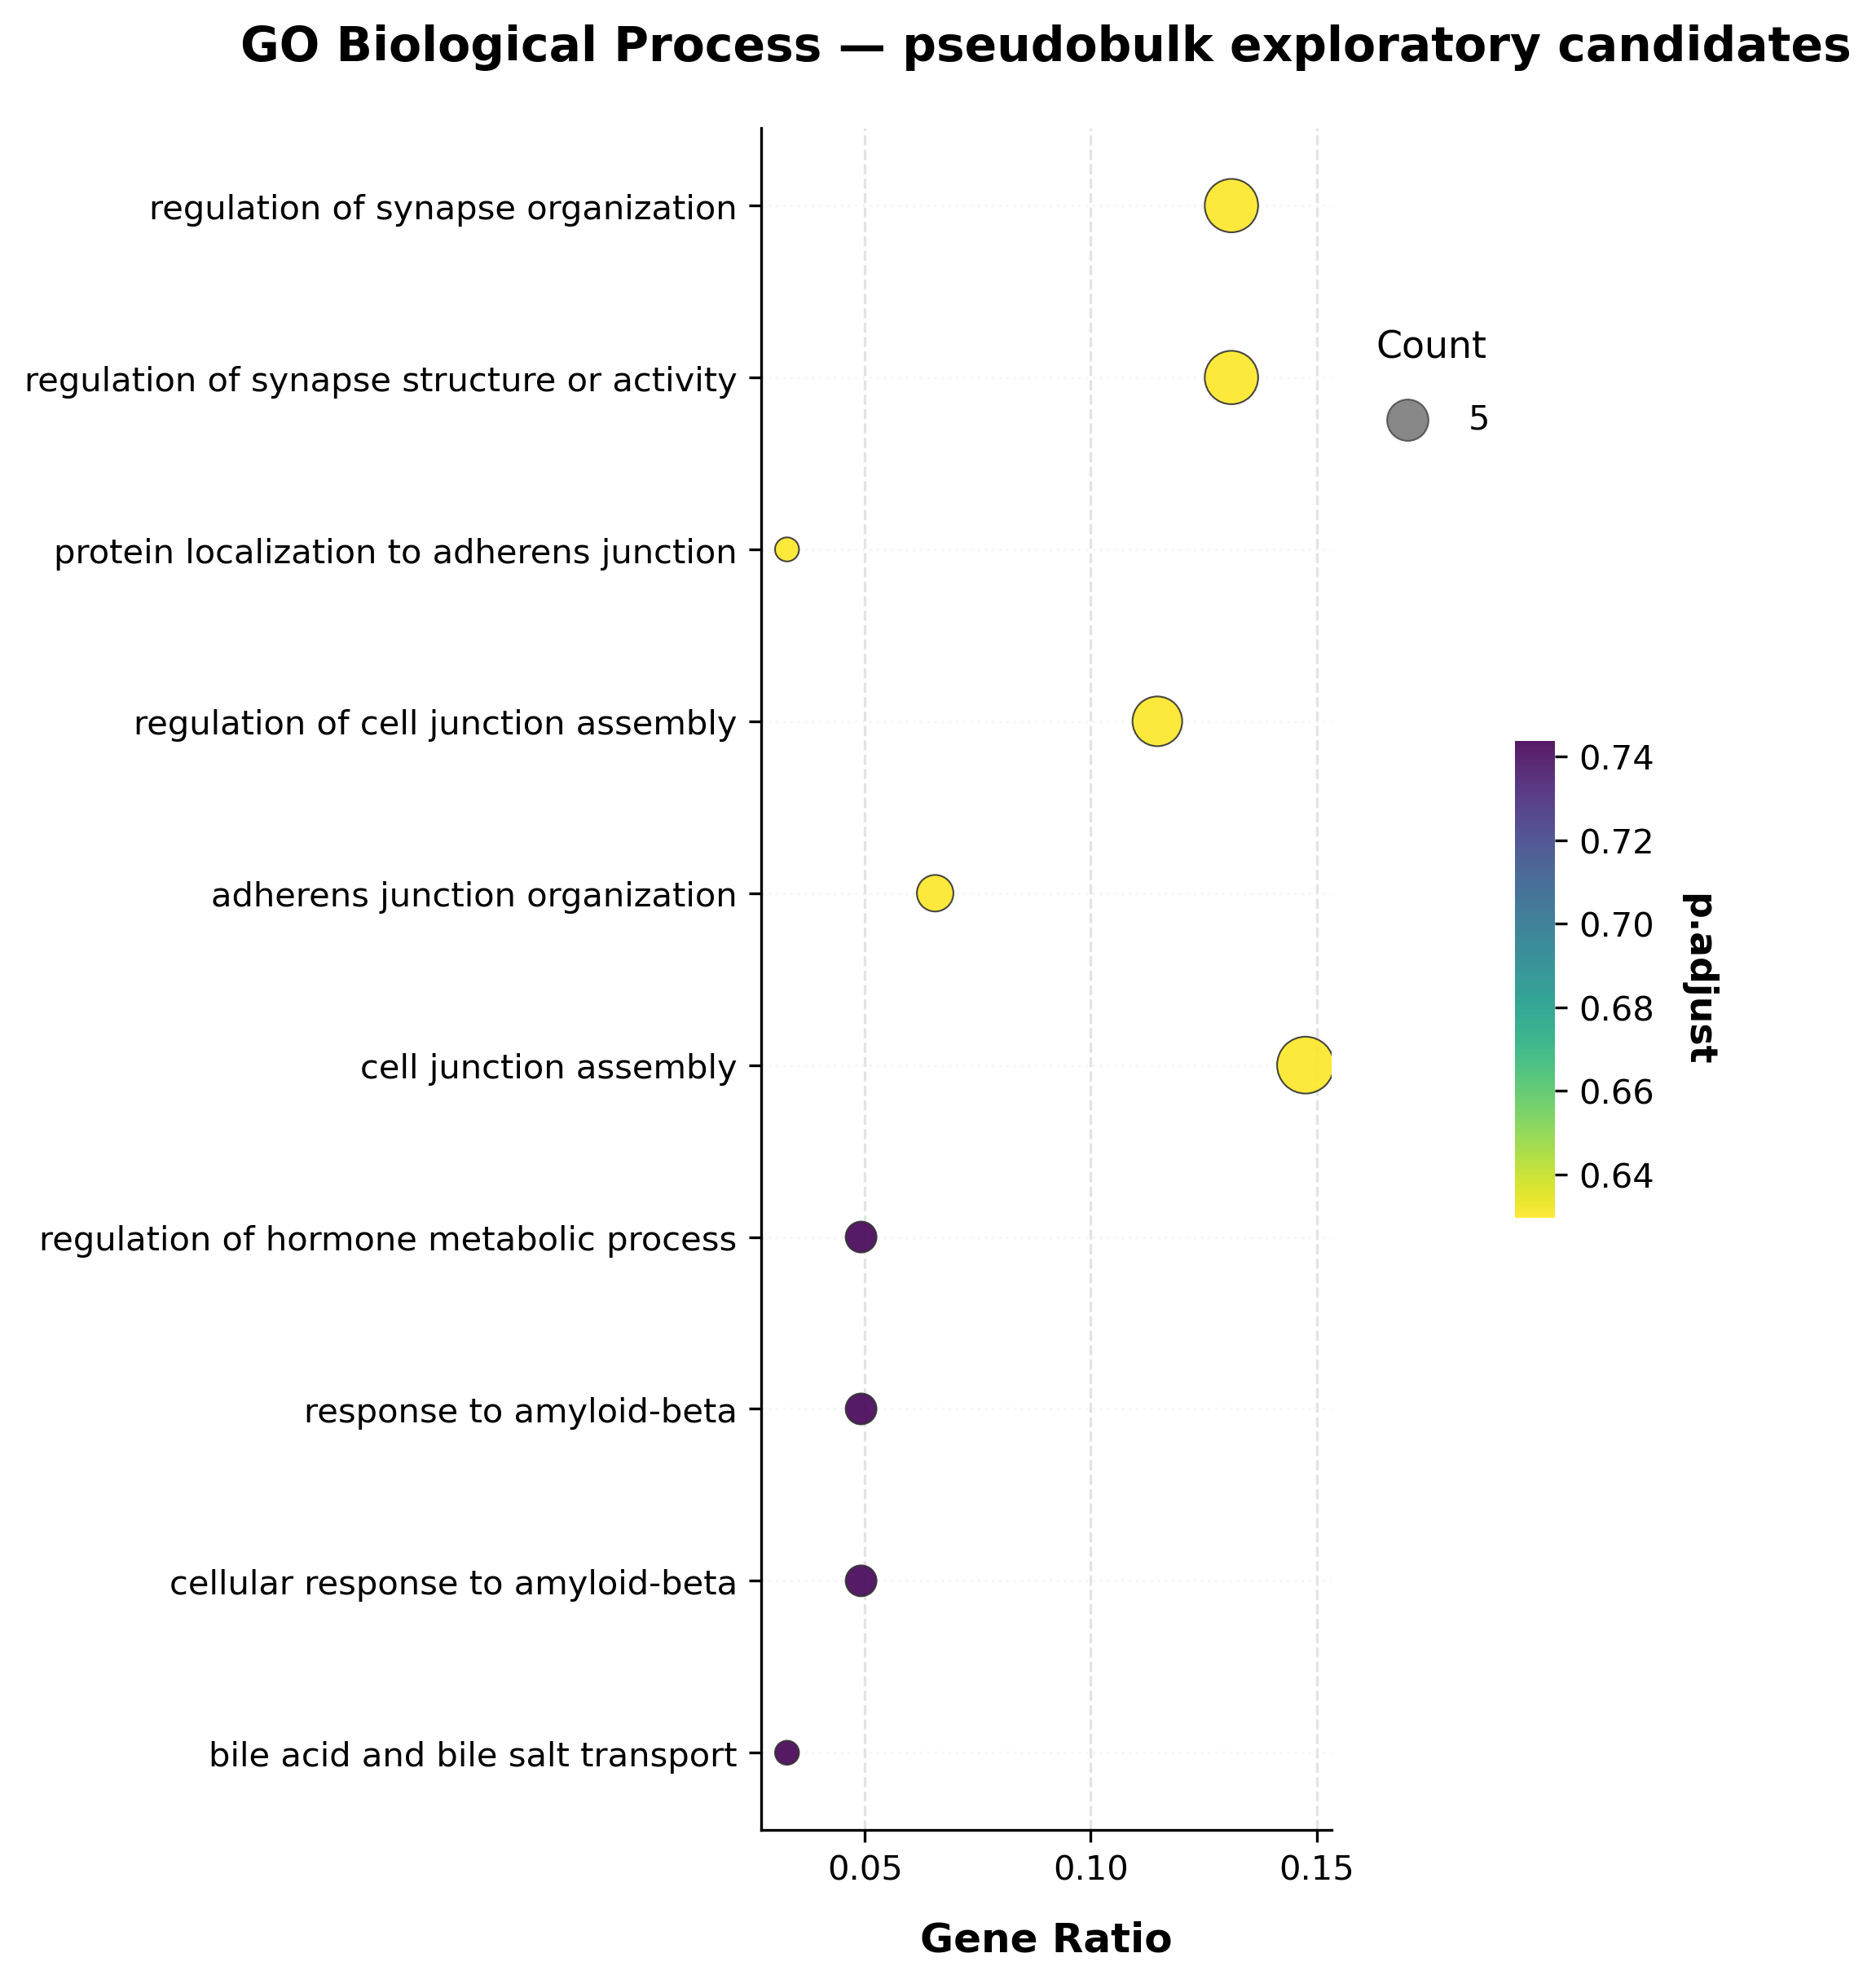

In [26]:
if len(enrich_res):
    scat.pl.enrich_dotplot(enrich_res, top_n=10, title="GO Biological Process — pseudobulk exploratory candidates")
else:
    print("No enrichment terms to plot.")

## Rank plot and expression heatmap for the top candidates

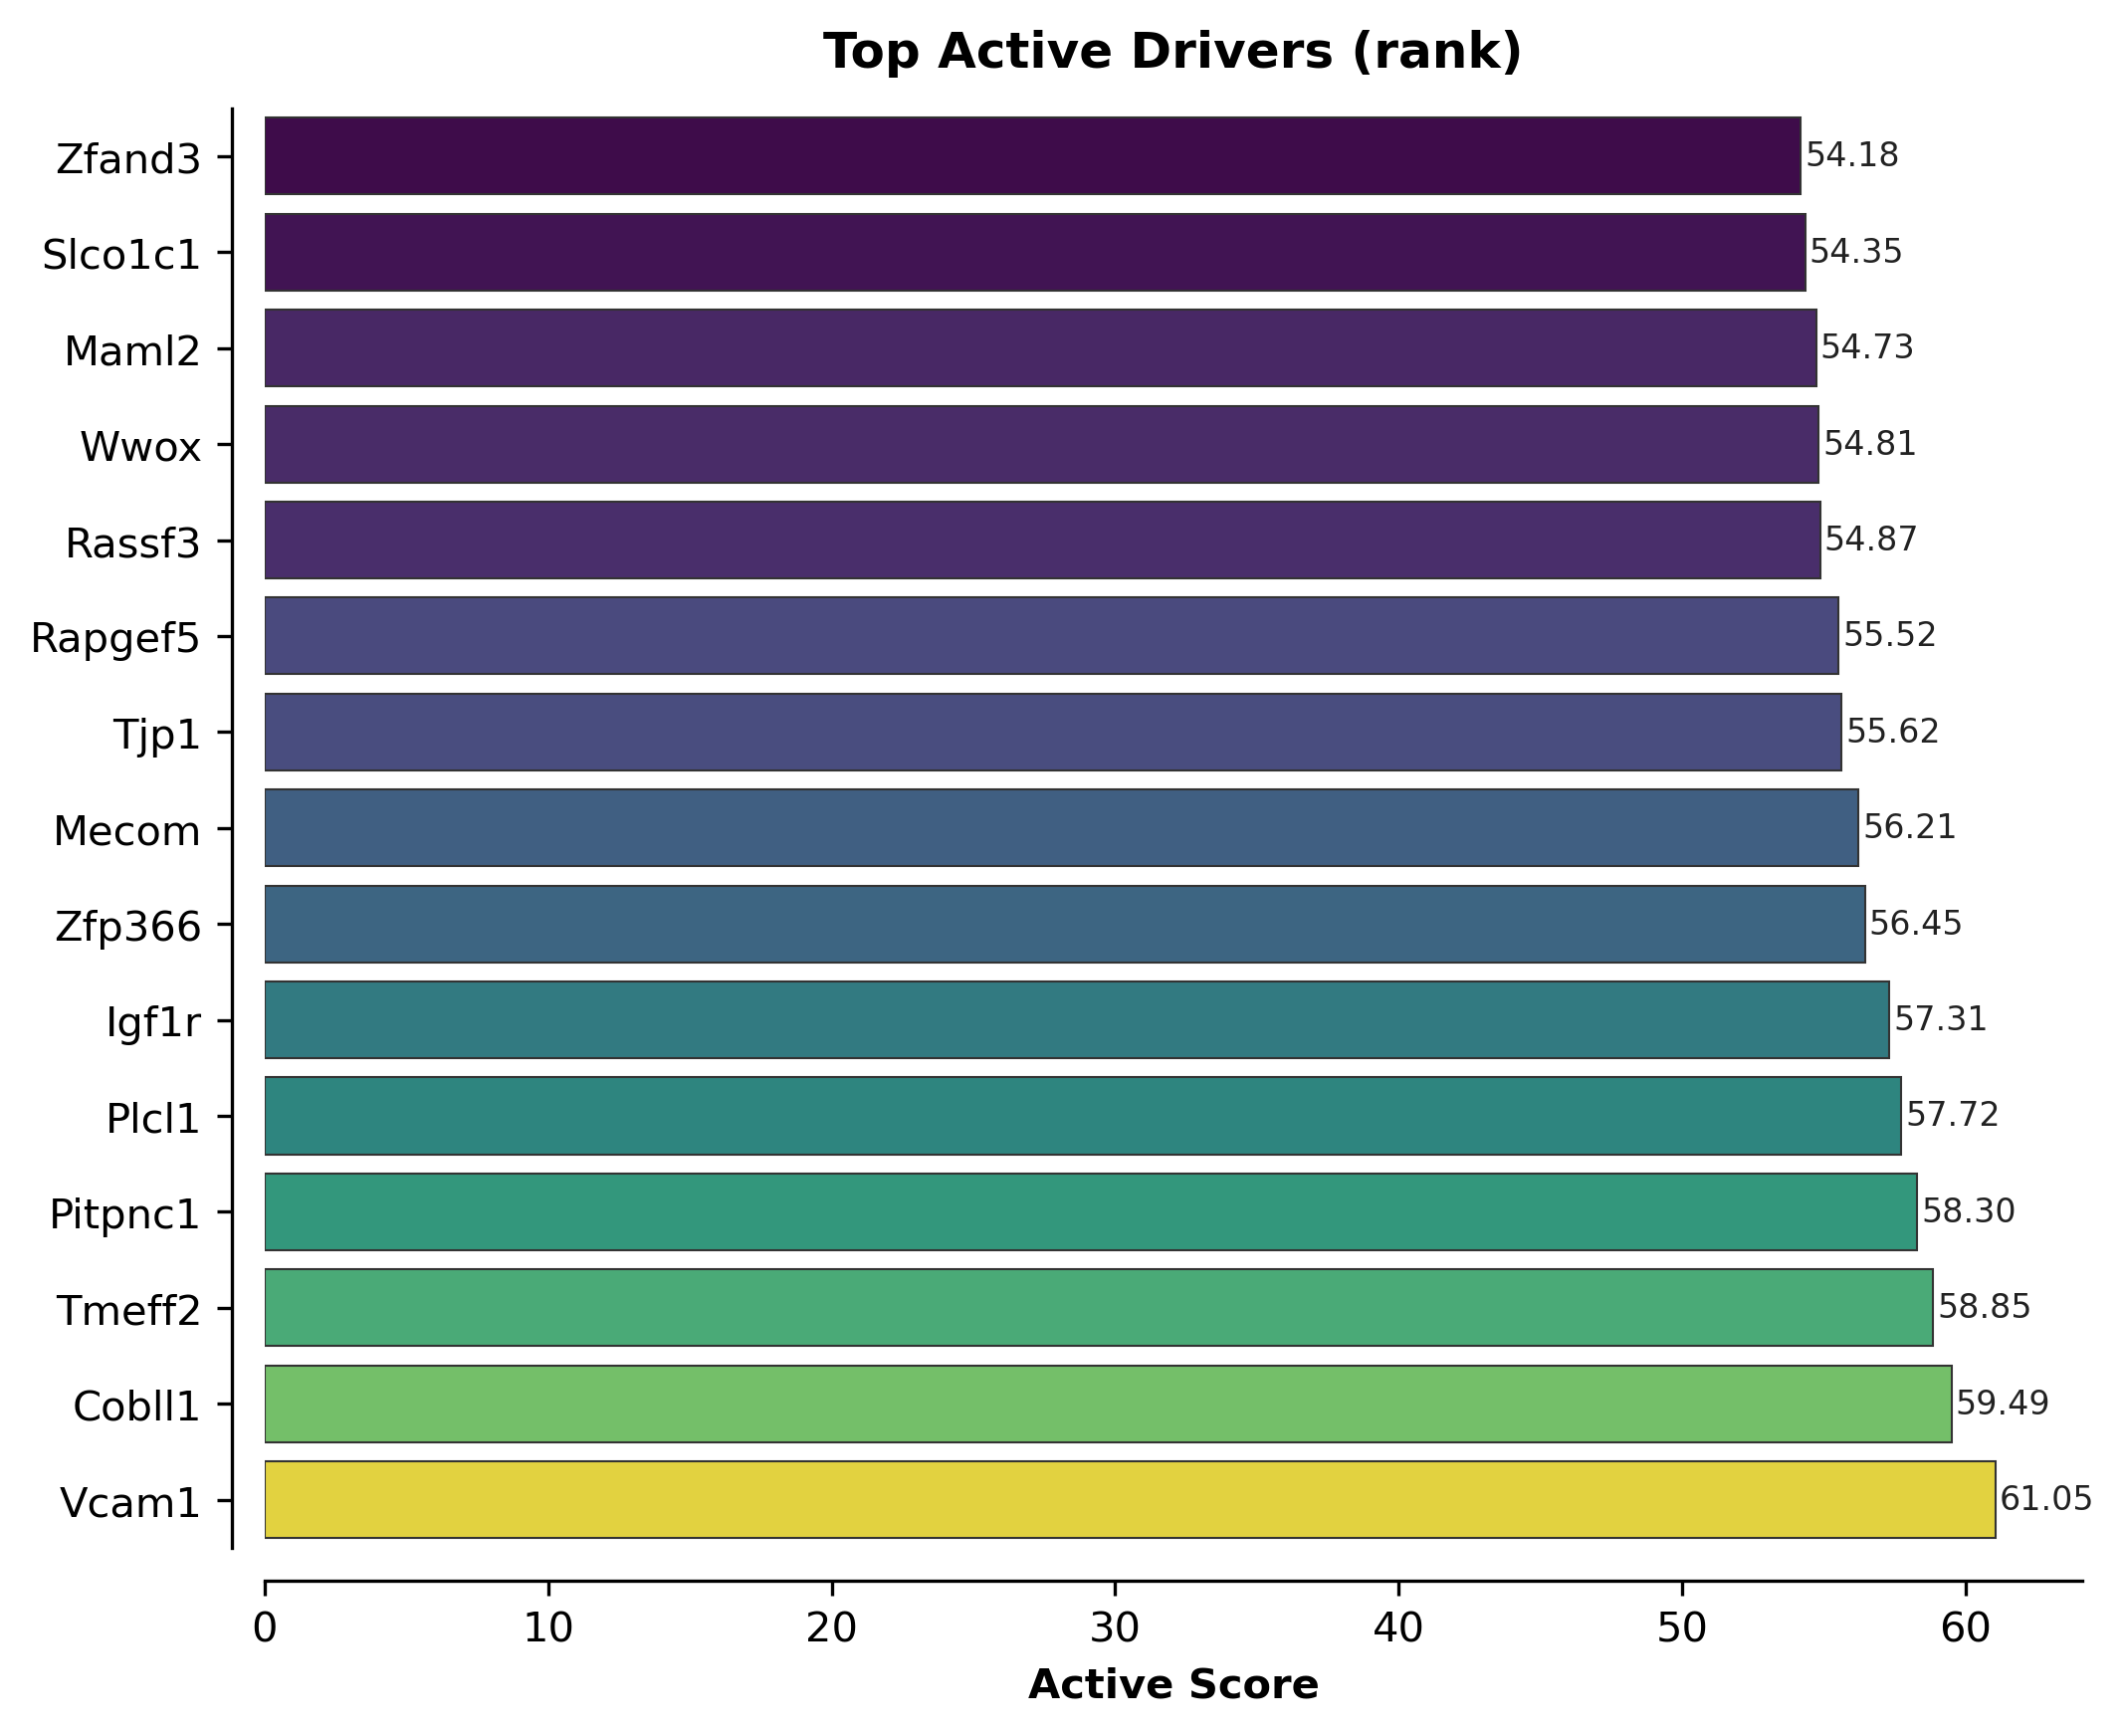

(<Figure size 2100x1710 with 1 Axes>,
 <Axes: title={'center': 'Top Active Drivers (rank)'}, xlabel='Active Score'>)

In [27]:
scat.pl.active_score_rankplot(all_results_pb.sort_values("active_score", ascending=False), top_n=15)

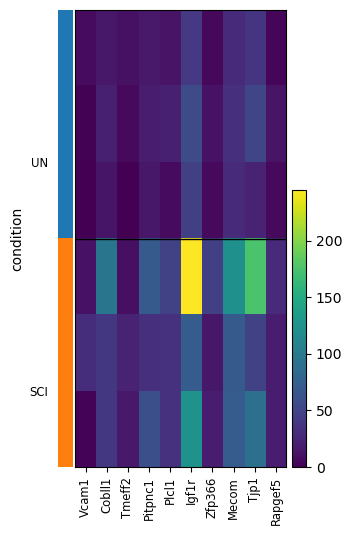

({'heatmap_ax': <Axes: >, 'groupby_ax': <Axes: ylabel='condition'>}, None)

In [28]:
top_genes = all_results_pb.sort_values("active_score", ascending=False).head(10).index.tolist()
scat.pl.active_genes_heatmap(adata_res_pb, genes=top_genes, groupby="condition")

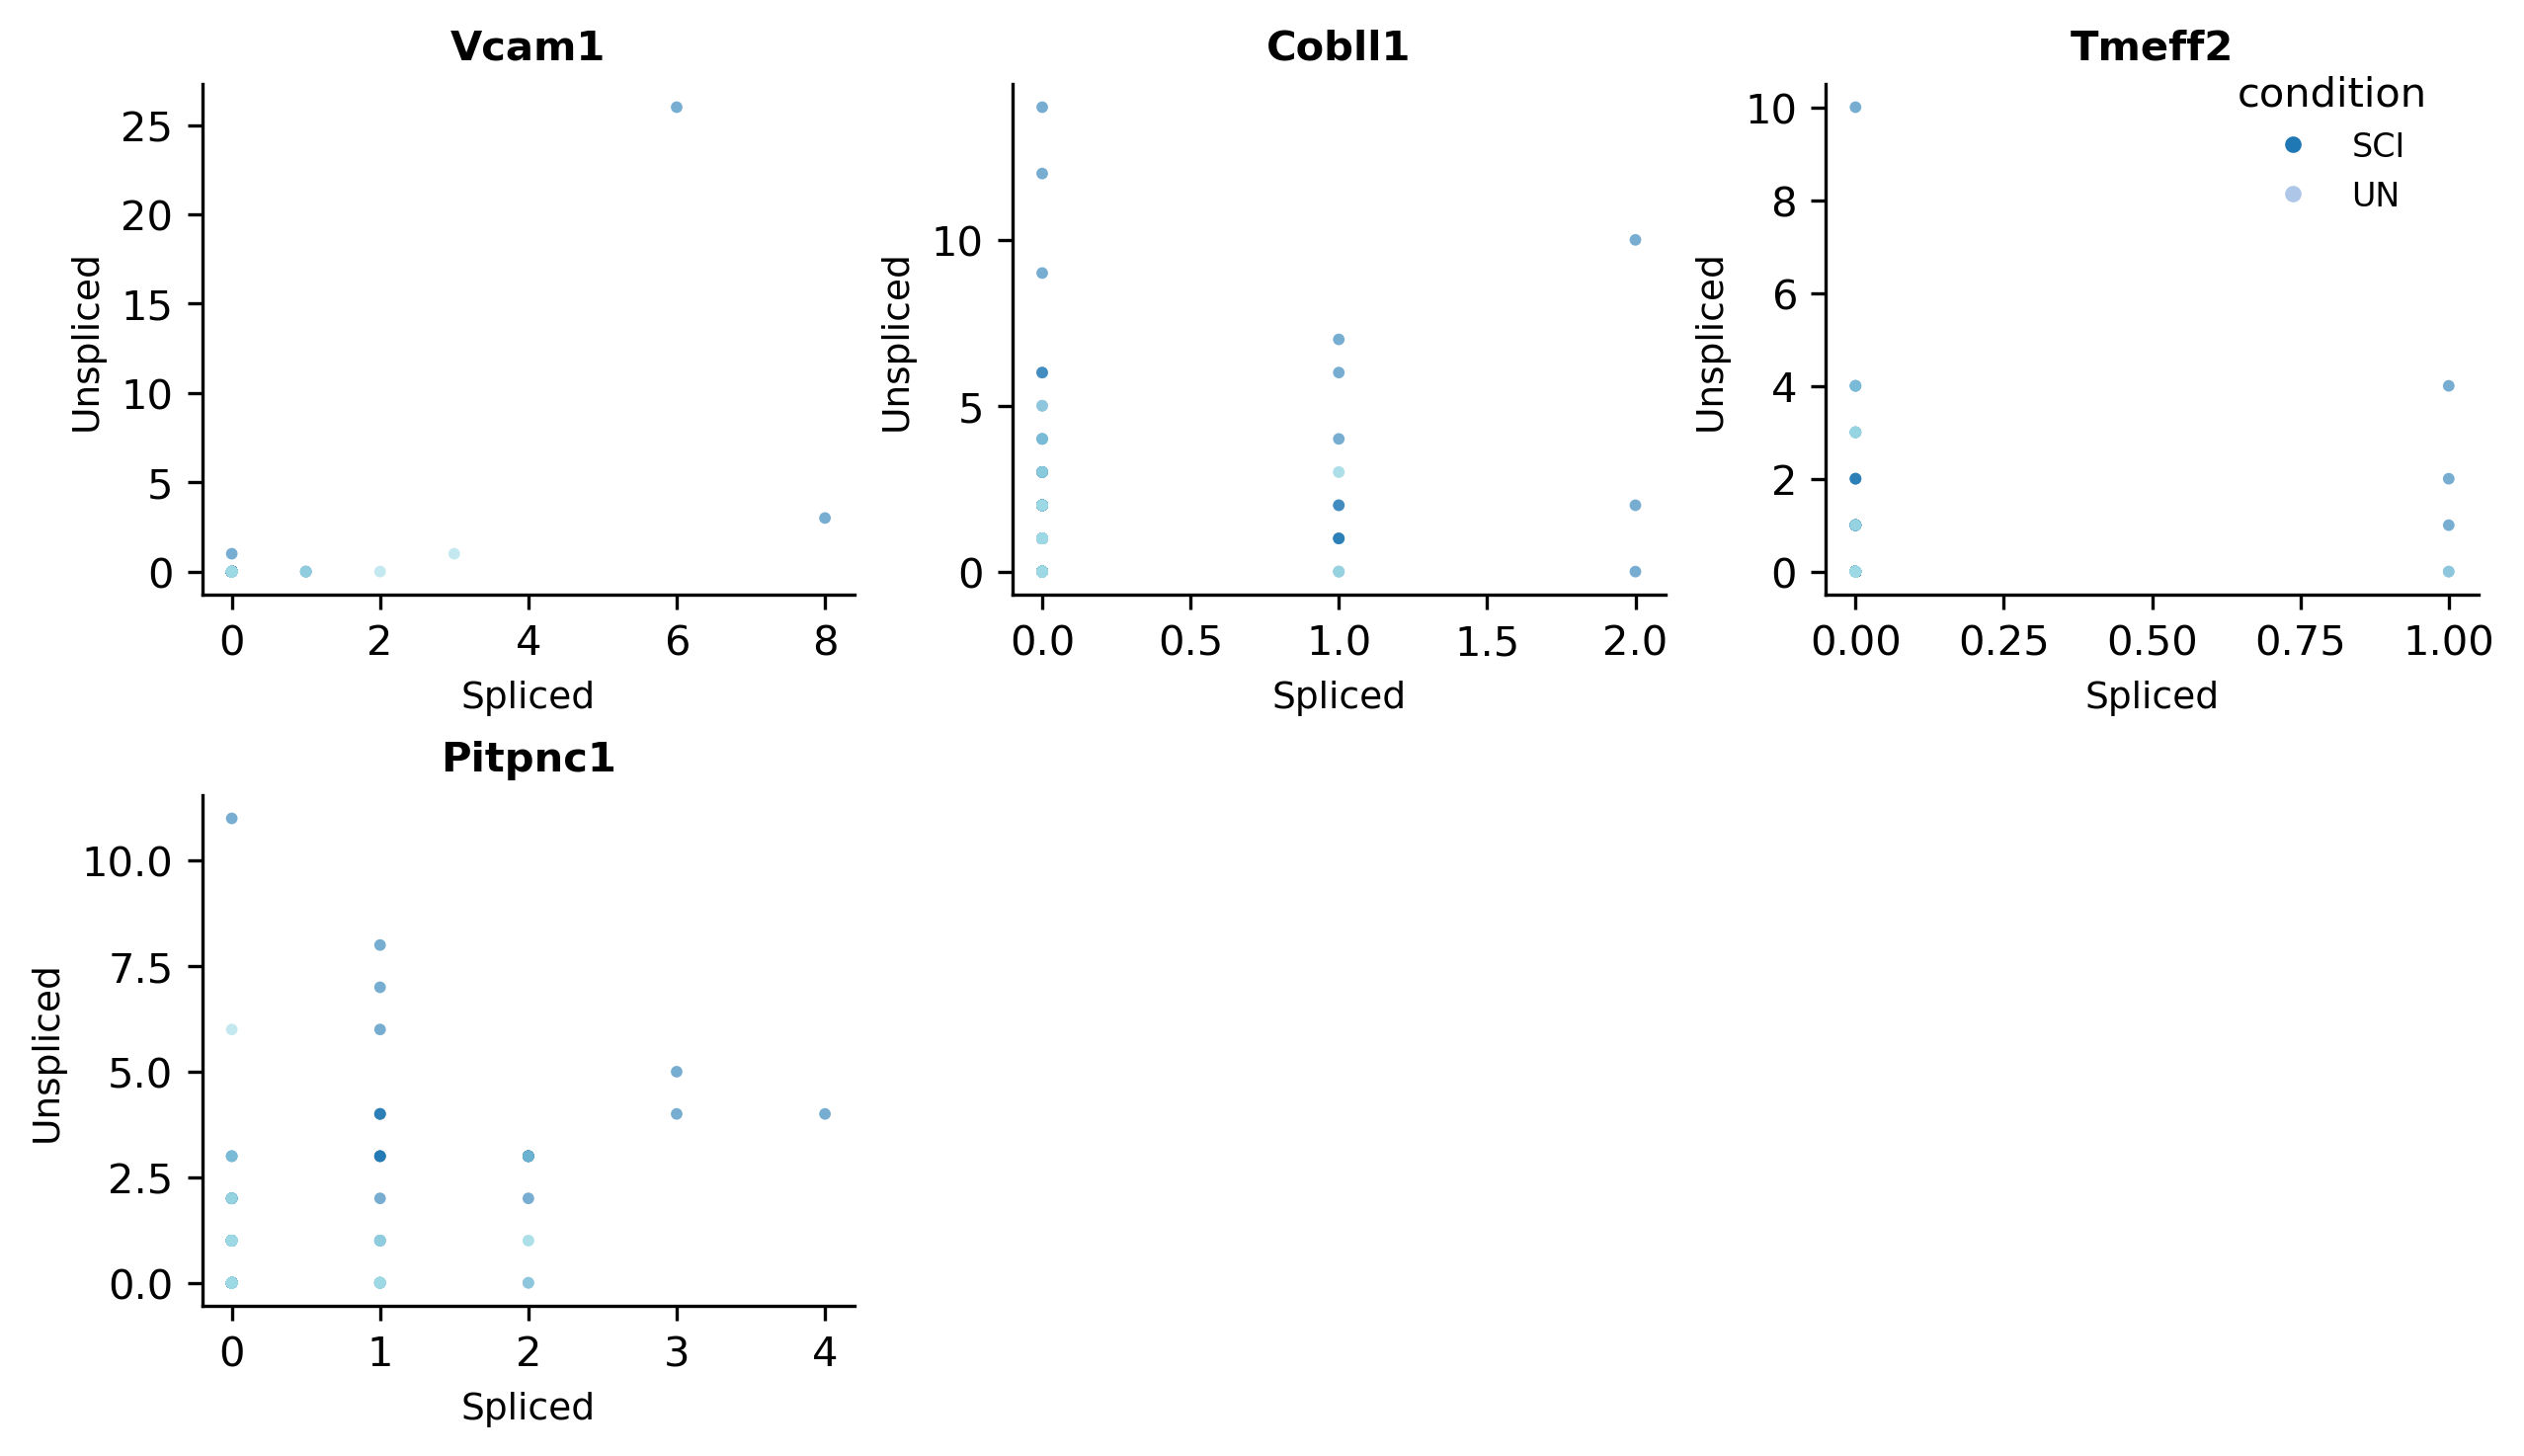

(<Figure size 2520x1440 with 6 Axes>,
 array([<Axes: title={'center': 'Vcam1'}, xlabel='Spliced', ylabel='Unspliced'>,
        <Axes: title={'center': 'Cobll1'}, xlabel='Spliced', ylabel='Unspliced'>,
        <Axes: title={'center': 'Tmeff2'}, xlabel='Spliced', ylabel='Unspliced'>,
        <Axes: title={'center': 'Pitpnc1'}, xlabel='Spliced', ylabel='Unspliced'>,
        <Axes: >, <Axes: >], dtype=object))

In [29]:
scat.pl.velocity_phase_portraits(adata, genes=top_genes[:4], groupby="condition")

## Recap

- `diagnose_design` / `recommend_workflow` read the experimental design
  (here: 3 vs. 3 samples, ~30% unspliced) and steer you toward
  pseudobulk + PyDESeq2 rather than a mixed model or permutation FDR.
- On this real, modestly-powered dataset, strict significance filters
  (`preset="pseudobulk"`, `preset="significant"`, permutation FDR) all
  legitimately return **no genes** — that is the honest answer for a 3 vs. 3
  design, not a failure of the tool.
- `active_score` and `filter_active_genes` with relaxed, explicit cutoffs
  still produce a usable **ranked candidate list** for downstream enrichment
  and hypothesis generation.
- Always report `active_score` as a composite heuristic rank, not a
  p-value — see {doc}`../statistical_guidance` for the full reporting
  checklist, {doc}`../user_guide/advanced` for every option shown above, and
  {doc}`../references` for the data and method citations.